In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingRegressor
# from sklearn




import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Indian Cities AQI.csv')
df.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


## $$Data Screening$$

Getting a better understanding of the data

---

In [3]:
print(df.isna().sum())

df.info()

date                                  0
state                                 0
area                                  0
number_of_monitoring_stations         0
prominent_pollutants                  0
aqi_value                             0
air_quality_status                    0
unit                                  0
note                             235785
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  str    
 1   state                          235785 non-null  str    
 2   area                           235785 non-null  str    
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  str    
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status             2357

In [4]:
df.describe()

,number_of_monitoring_stations,aqi_value,note
count,235785.000000,235785.000000,0.0
mean,1.870653,111.127294,NaN
std,3.071575,71.447353,NaN
min,1.000000,3.000000,NaN
25%,1.000000,59.000000,NaN
50%,1.000000,92.000000,NaN
75%,1.000000,142.000000,NaN
max,40.000000,500.000000,NaN


In [5]:
df.nunique()

date                             1125
state                              32
area                              291
number_of_monitoring_stations      40
prominent_pollutants               49
aqi_value                         472
air_quality_status                  6
unit                                1
note                                0
dtype: int64

In [6]:
df['prominent_pollutants'].unique()

<ArrowStringArray>
[             'PM10',                'CO',                'O3',
             'PM2.5',               'SO2',        'PM2.5,PM10',
          'PM10,NO2',           'PM10,O3',     'O3,PM2.5,PM10',
        'PM10,O3,CO',           'PM10,CO',          'PM2.5,O3',
          'PM10,SO2',       'PM2.5,CO,O3',               'NO2',
    'PM10,PM2.5,NO2',             'CO,O3',     'PM2.5,PM10,CO',
      'PM2.5,SO2,O3',       'PM10,NO2,O3',            'SO2,O3',
       'PM10,NH3,CO', 'PM10,NO2,PM2.5,O3',       'NO2,PM10,CO',
            'CO,SO2',         'PM2.5,NO2',       'PM10,CO,SO2',
     'PM2.5,NO2,SO2',       'PM10,SO2,O3',      'PM10,NO2,SO3',
      'PM2.5,NH3,O3',    'PM10,PM2.5,SO2',            'NO2,O3',
         'PM2.5,SO2',            'CO,NO2',               'NH3',
      'PM2.5,CO,NO2',         'PM2.5,NH3',           'NO2,SO2',
      'PM2.5,CO,SO2',         'SO3,CO,O3',         'NO2,CO,O3',
        'NO2,SO2,CO',        'NO2,O3,SO2',          'PM10,NH3',
         'NH3,CO,O3',

In [7]:
# # removing the useless feature

df.drop(columns=['note', 'unit'], inplace=True)

In [8]:
# splitting the pollutant column

col_split = df['prominent_pollutants'].str.split(',', expand=True)


df['pollutant 1'] = col_split.get(0)
df['pollutant 2'] = col_split.get(1)
df['pollutant 3'] = col_split.get(2)

df.drop(columns=['prominent_pollutants'], inplace=True)

print(df.shape)

# checking for missing values in polllutant 2 and 3
print(df['pollutant 2'].isna().sum())
print(df['pollutant 3'].isna().sum())


df.head()




(235785, 9)
206688
232343


,date,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,pollutant 1,pollutant 2,pollutant 3
0,30-04-2025,Maharashtra,Amravati,2,78,Satisfactory,PM10,NaN,NaN
1,30-04-2025,Bihar,Purnia,1,56,Satisfactory,CO,NaN,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,98,Satisfactory,O3,NaN,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,103,Moderate,PM10,NaN,NaN
4,30-04-2025,Assam,Byrnihat,1,61,Satisfactory,PM2.5,NaN,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype
---  ------                         --------------   -----
 0   date                           235785 non-null  str  
 1   state                          235785 non-null  str  
 2   area                           235785 non-null  str  
 3   number_of_monitoring_stations  235785 non-null  int64
 4   aqi_value                      235785 non-null  int64
 5   air_quality_status             235785 non-null  str  
 6   pollutant 1                    235785 non-null  str  
 7   pollutant 2                    29097 non-null   str  
 8   pollutant 3                    3442 non-null    str  
dtypes: int64(2), str(7)
memory usage: 25.2 MB


## $$Visualization$$
---

In [10]:
color=df['air_quality_status']

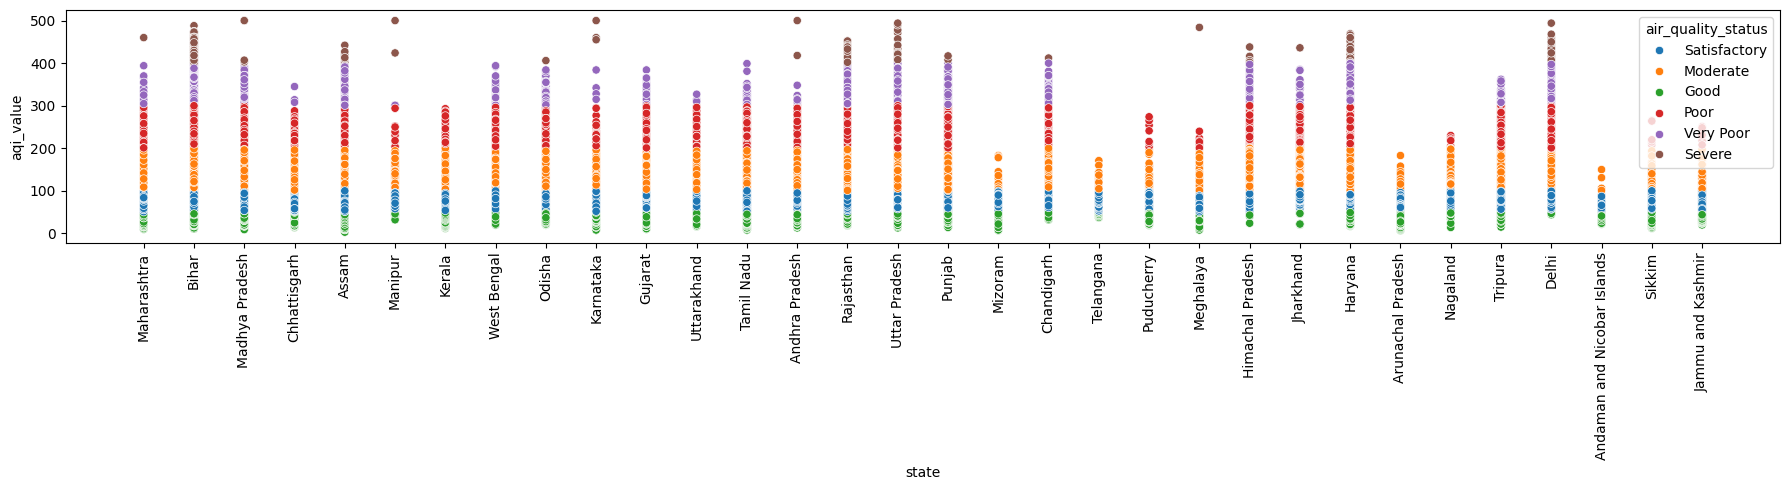

In [11]:
plt.figure(figsize=(18,5))

sns.scatterplot(data=df, x='state', y='aqi_value', hue='air_quality_status')
# Rotate x-axis labels by 90 degrees
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [12]:
# printng the areas that come under odisha


# as we can see there are total 11099 rows for odisha, but are only 16 areas of odisha which are mentioned here
print(df[df['state'] == 'Odisha']['area'].unique())

df[df['state'] == 'Odisha']

<ArrowStringArray>
[    'Nayagarh',  'Bhubaneswar',     'Balasore',        'Angul',
     'Keonjhar',      'Talcher',   'Byasanagar',     'Rourkela',
      'Suakati',     'Baripada',      'Cuttack', 'Brajrajnagar',
       'Barbil',   'Rairangpur',        'Tensa',    'Bileipada']
Length: 16, dtype: str


,date,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,pollutant 1,pollutant 2,pollutant 3
8,30-04-2025,Odisha,Nayagarh,1,58,Satisfactory,PM10,NaN,NaN
39,30-04-2025,Odisha,Bhubaneswar,2,94,Satisfactory,CO,NaN,NaN
44,30-04-2025,Odisha,Balasore,1,87,Satisfactory,O3,NaN,NaN
48,30-04-2025,Odisha,Angul,1,156,Moderate,O3,NaN,NaN
54,30-04-2025,Odisha,Keonjhar,1,71,Satisfactory,PM10,NaN,NaN
...,...,...,...,...,...,...,...,...,...
235195,04-04-2022,Odisha,Talcher,1,81,Satisfactory,CO,NaN,NaN
235590,02-04-2022,Odisha,Brajrajnagar,1,111,Moderate,PM10,NaN,NaN
235633,02-04-2022,Odisha,Talcher,1,86,Satisfactory,CO,NaN,NaN
235684,01-04-2022,Odisha,Talcher,1,37,Good,PM10,NaN,NaN


In [13]:
# checking the details for the Bhubaneswar location
print(df[df['state'] == 'Odisha'][df['area'] == 'Bhubaneswar'].shape)
df[df['state'] == 'Odisha'][df['area'] == 'Bhubaneswar']

(531, 9)


,date,state,area,number_of_monitoring_stations,aqi_value,air_quality_status,pollutant 1,pollutant 2,pollutant 3
39,30-04-2025,Odisha,Bhubaneswar,2,94,Satisfactory,CO,NaN,NaN
402,29-04-2025,Odisha,Bhubaneswar,2,62,Satisfactory,CO,O3,NaN
575,28-04-2025,Odisha,Bhubaneswar,2,72,Satisfactory,CO,O3,NaN
837,27-04-2025,Odisha,Bhubaneswar,2,89,Satisfactory,CO,O3,NaN
1044,26-04-2025,Odisha,Bhubaneswar,2,52,Satisfactory,PM10,CO,NaN
...,...,...,...,...,...,...,...,...,...
128328,06-11-2023,Odisha,Bhubaneswar,2,108,Moderate,PM2.5,NaN,NaN
128670,05-11-2023,Odisha,Bhubaneswar,2,85,Satisfactory,CO,NaN,NaN
128803,04-11-2023,Odisha,Bhubaneswar,2,84,Satisfactory,CO,NaN,NaN
129113,03-11-2023,Odisha,Bhubaneswar,2,64,Satisfactory,CO,NaN,NaN


In [14]:
df[df['state'] == 'Odisha']['area'].value_counts()

area
Talcher         956
Rourkela        872
Baripada        807
Suakati         799
Bileipada       781
Brajrajnagar    762
Keonjhar        755
Nayagarh        751
Tensa           750
Rairangpur      748
Bhubaneswar     531
Balasore        525
Barbil          519
Byasanagar      518
Cuttack         516
Angul           509
Name: count, dtype: int64

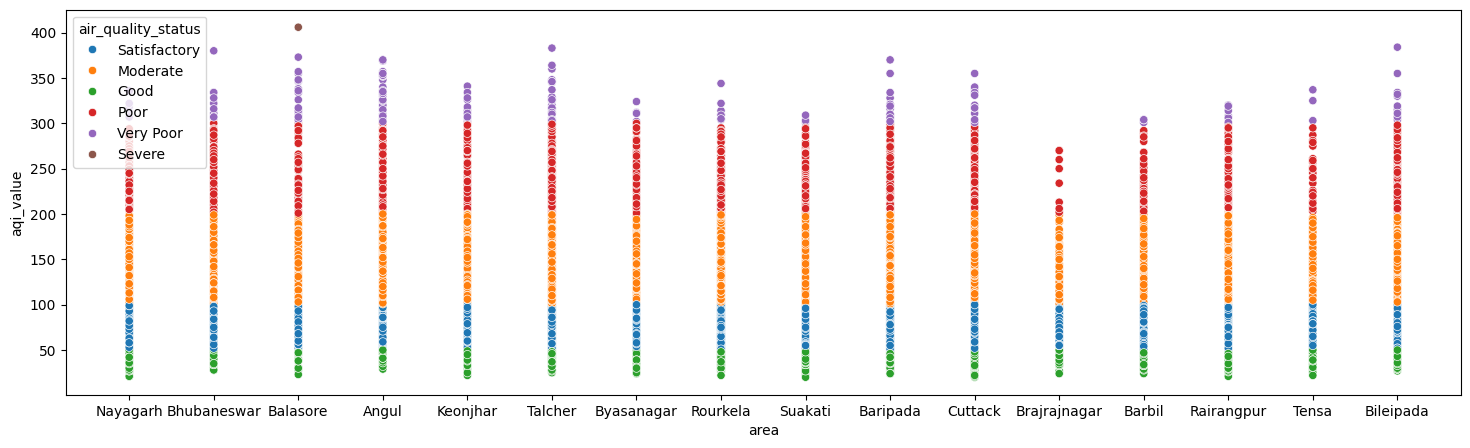

In [15]:
# plotting the aqi of cities of odisha

odisha = df[df['state'] == 'Odisha']


plt.figure(figsize=(18,5))
sns.scatterplot(data=odisha, x='area', y='aqi_value', hue=color)
plt.show()


In [66]:
more = df[df['state'] == 'Manipur']['area'].unique()


for i in df['state'].unique():
    if (df[df['state'] == i]['area'].nunique()) == 1:
        print(i)



Manipur
Mizoram
Chandigarh
Telangana
Puducherry
Meghalaya
Himachal Pradesh
Arunachal Pradesh
Nagaland
Tripura
Delhi
Andaman and Nicobar Islands
Sikkim
Jammu and Kashmir


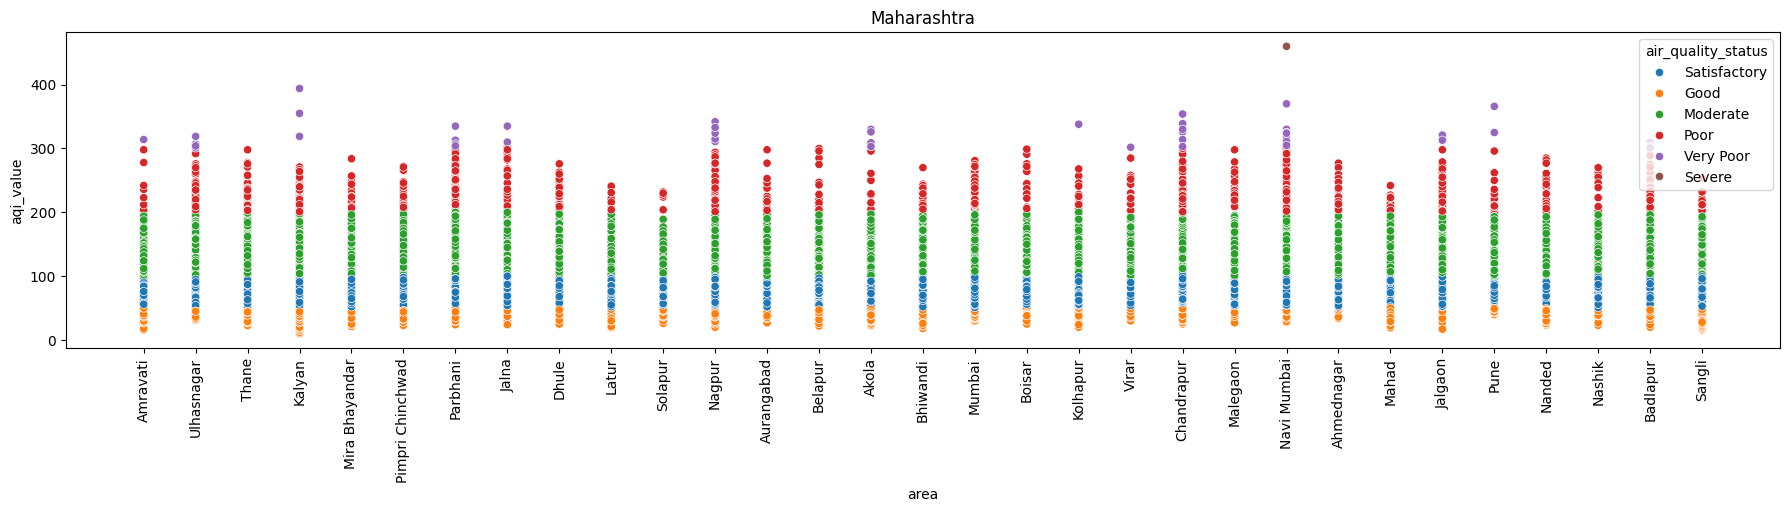

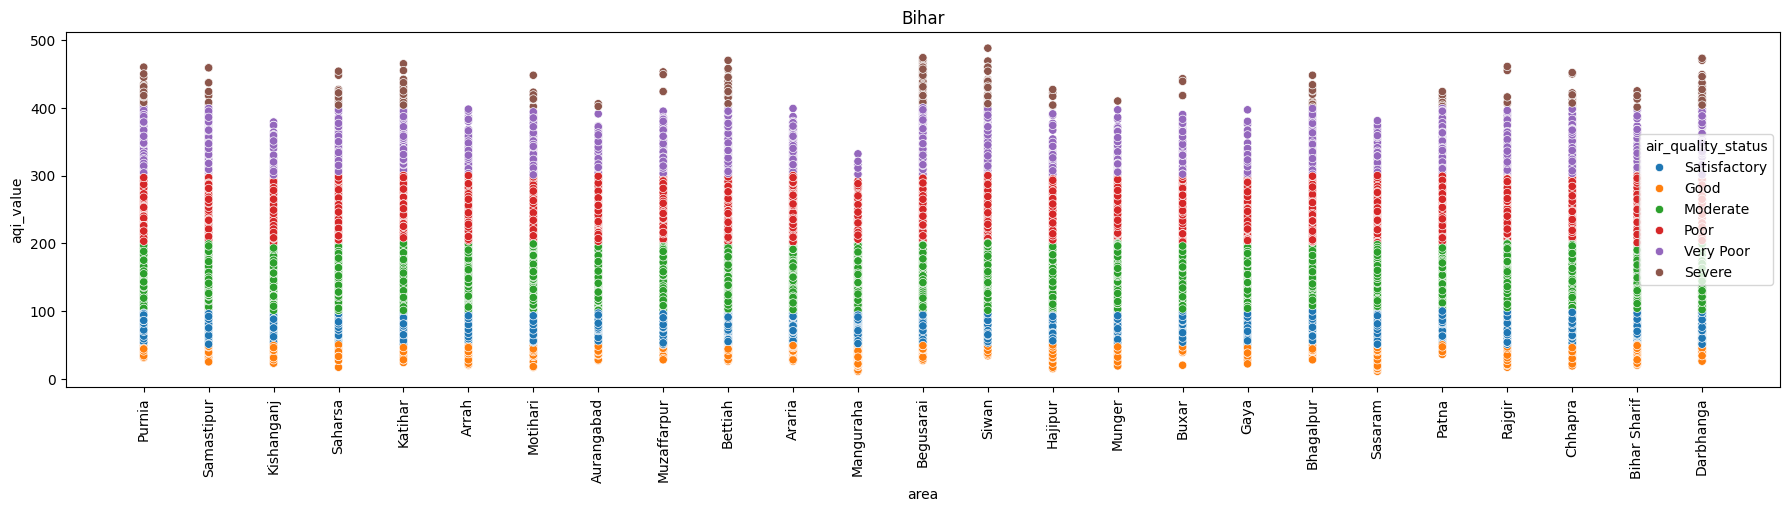

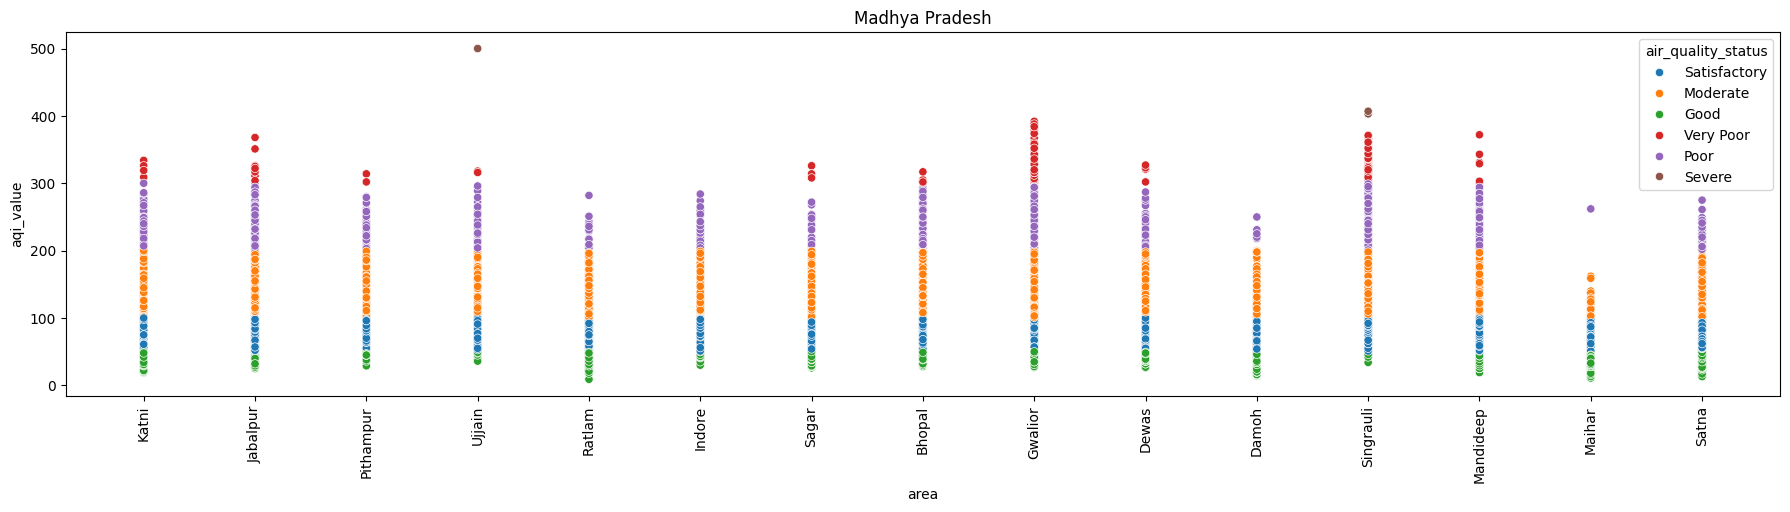

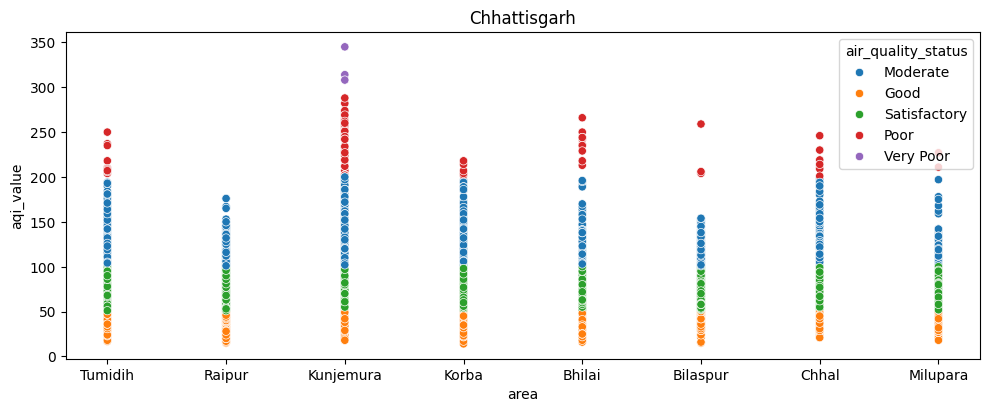

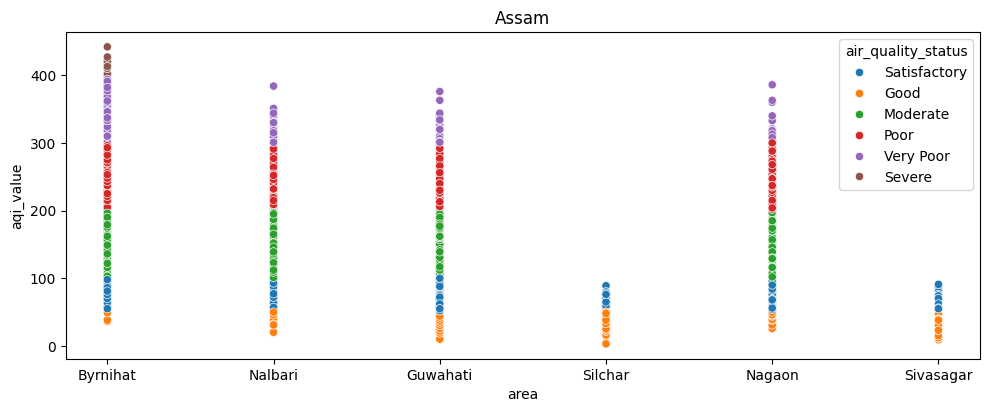

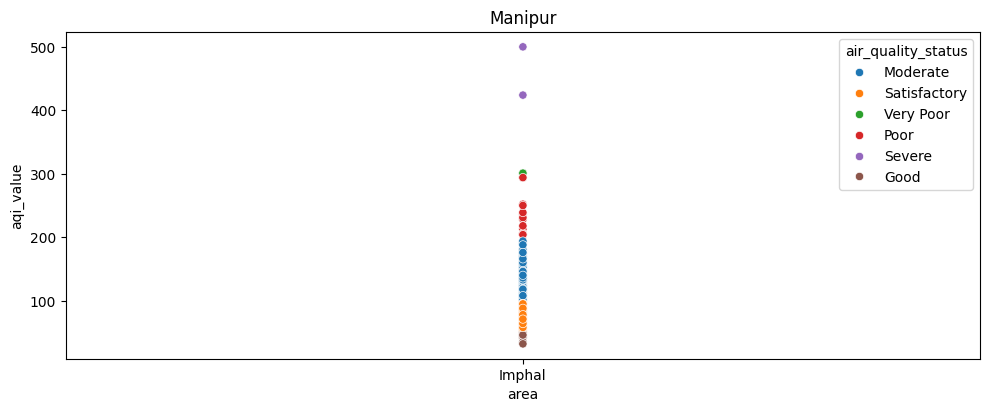

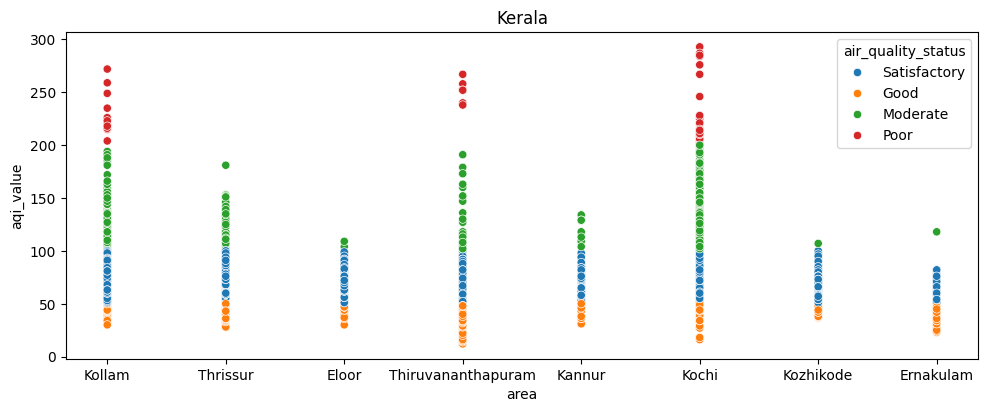

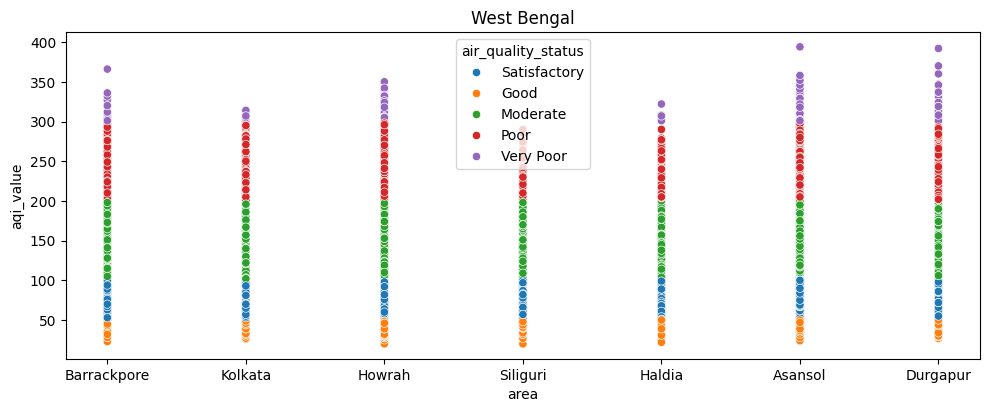

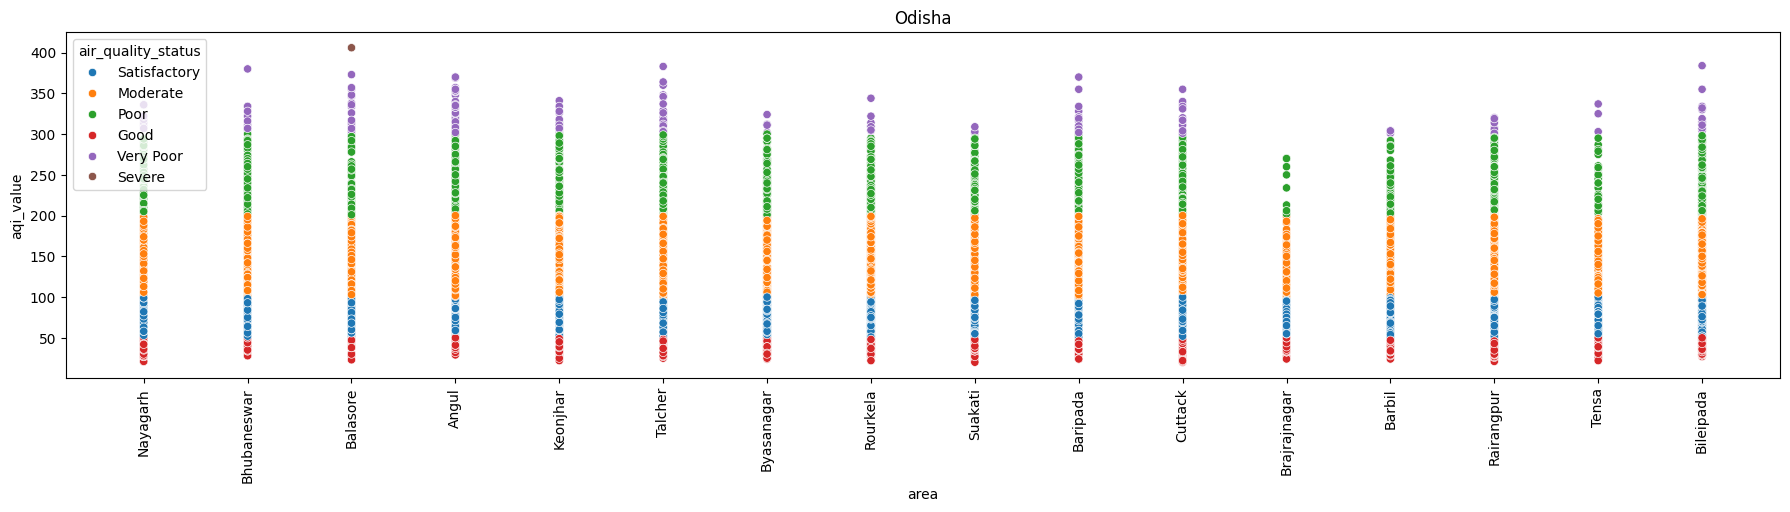

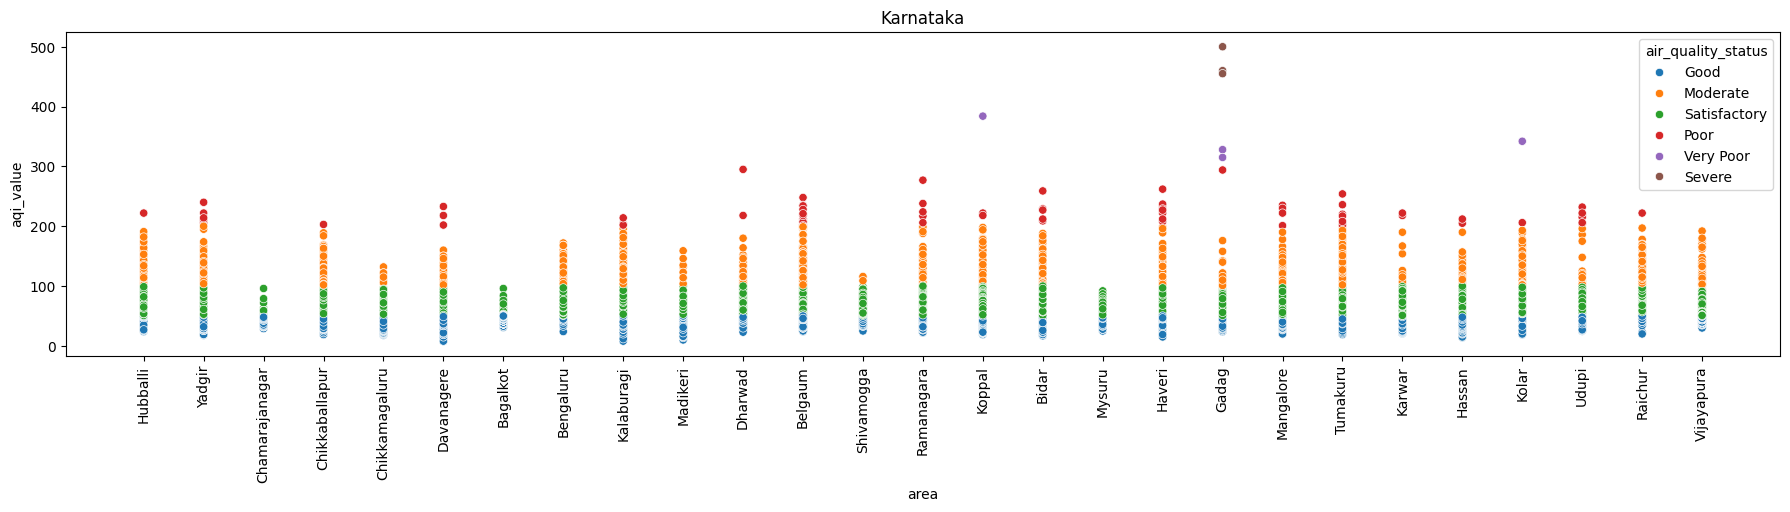

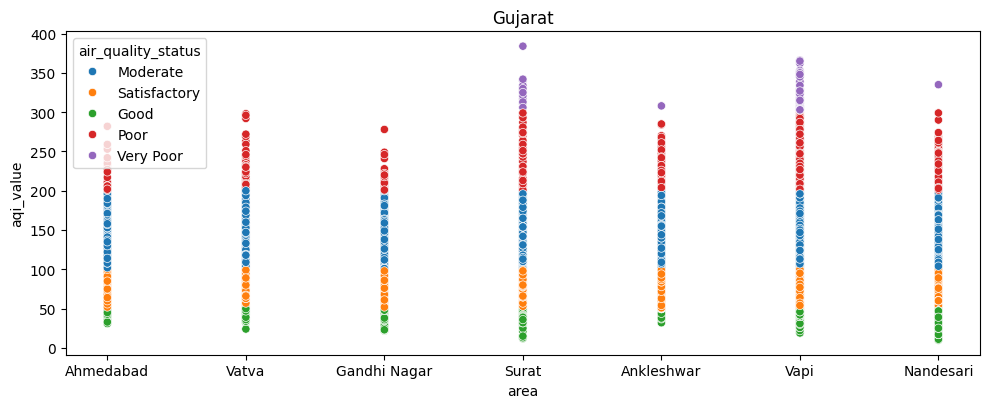

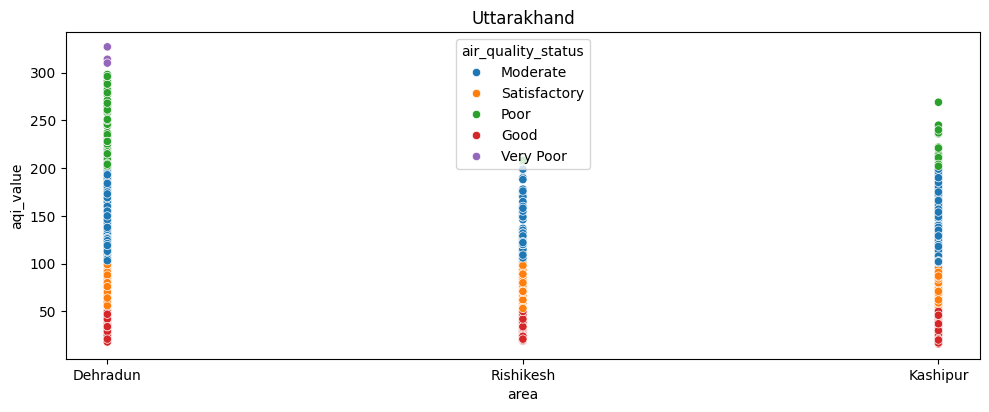

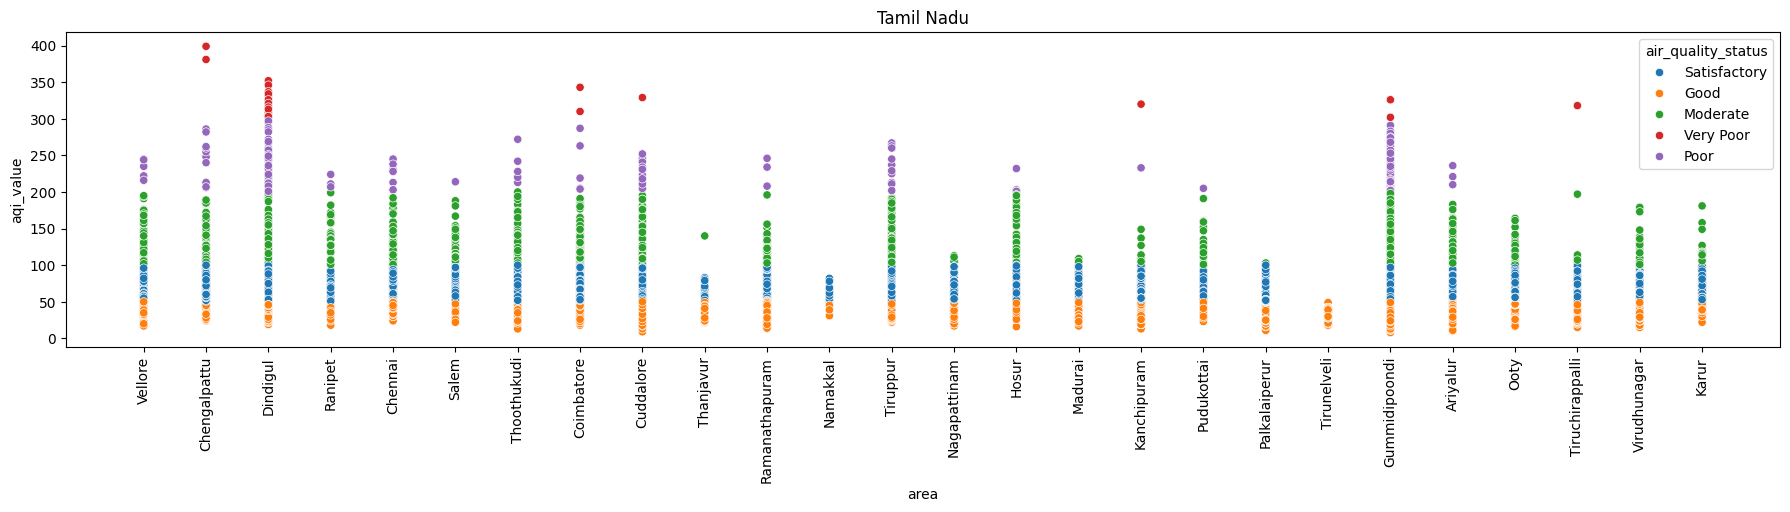

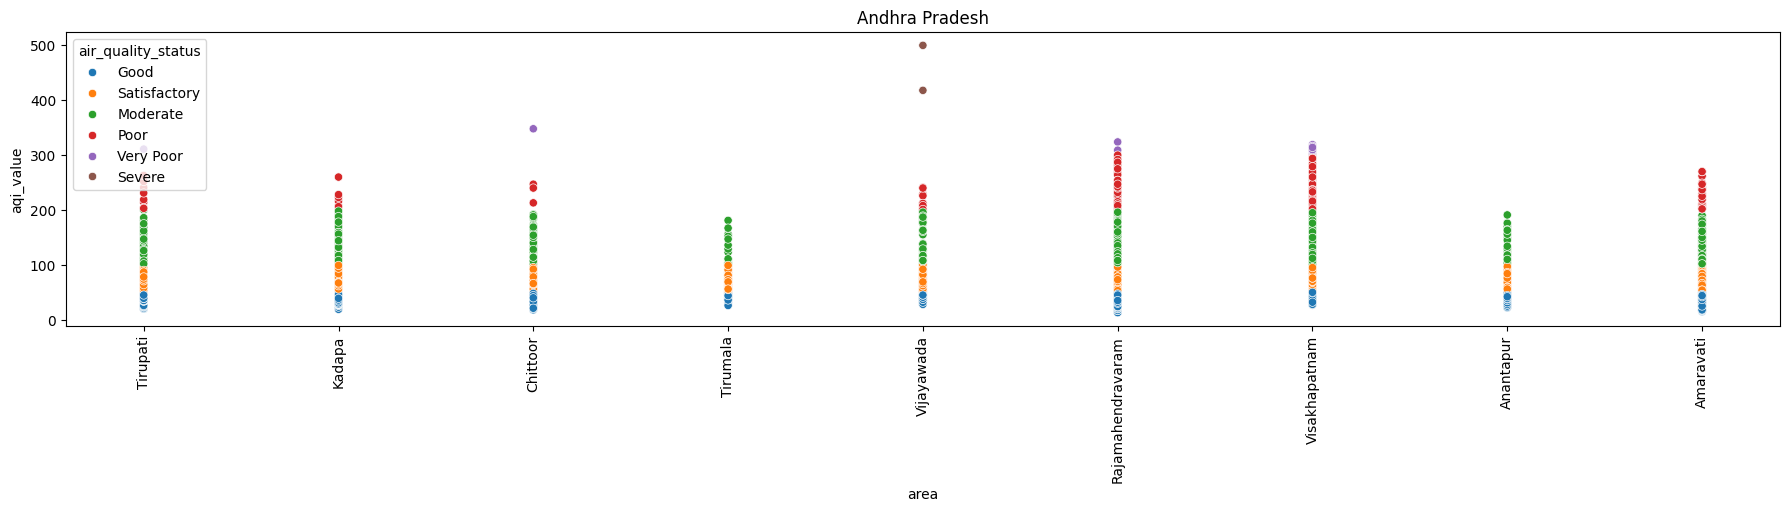

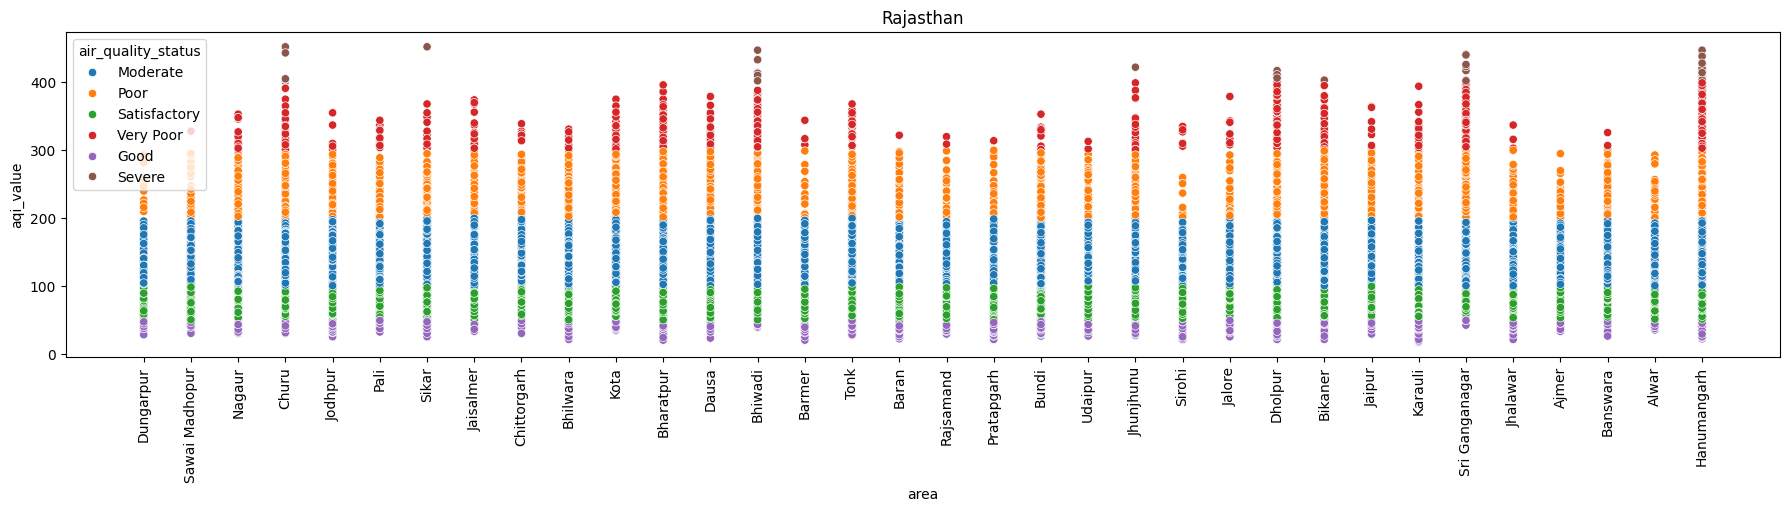

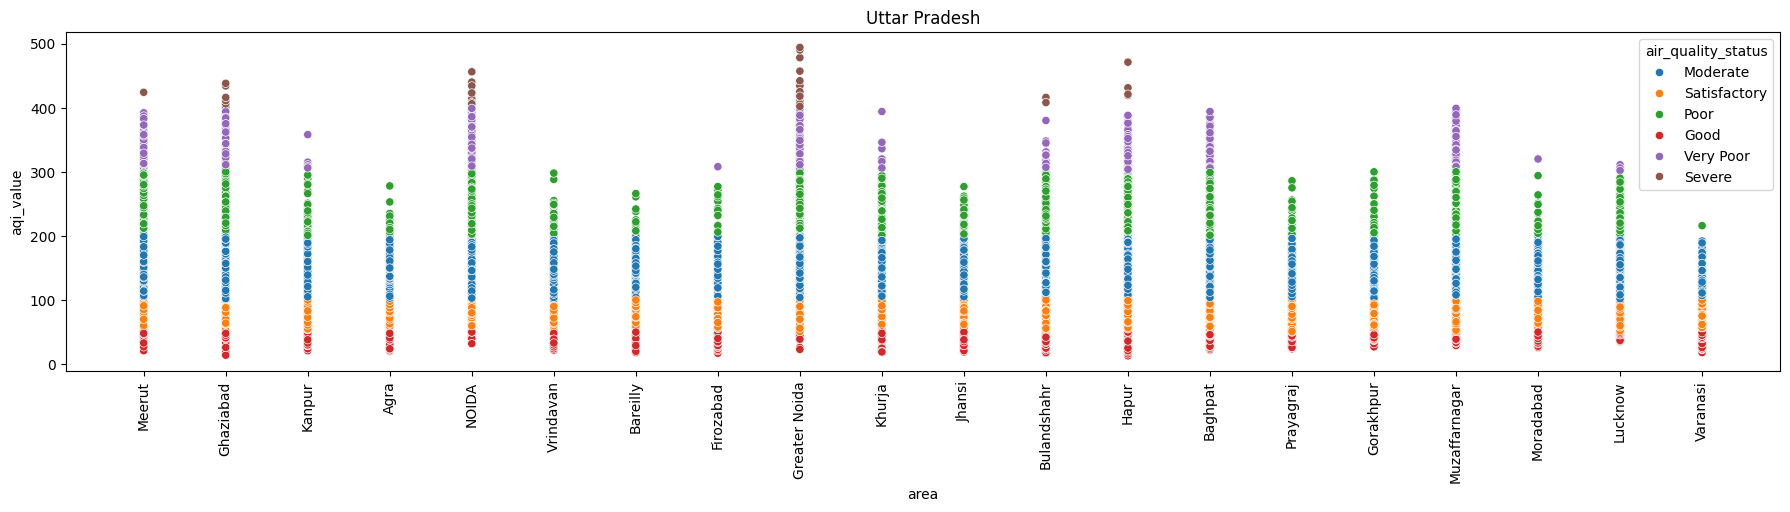

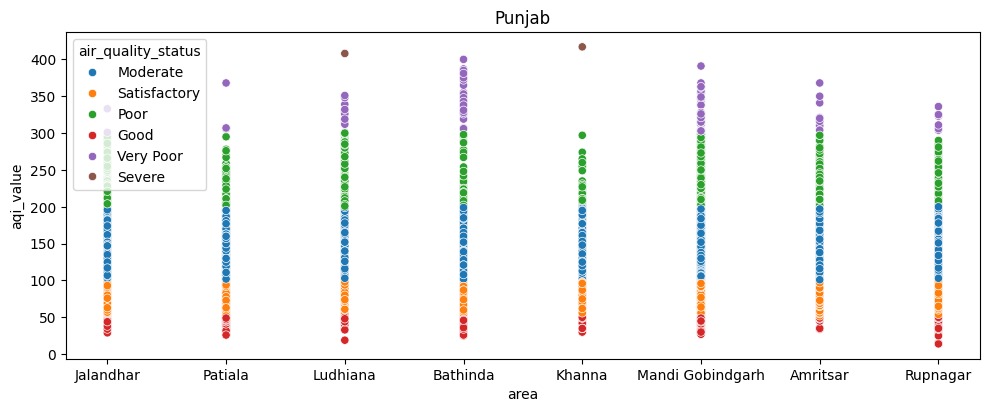

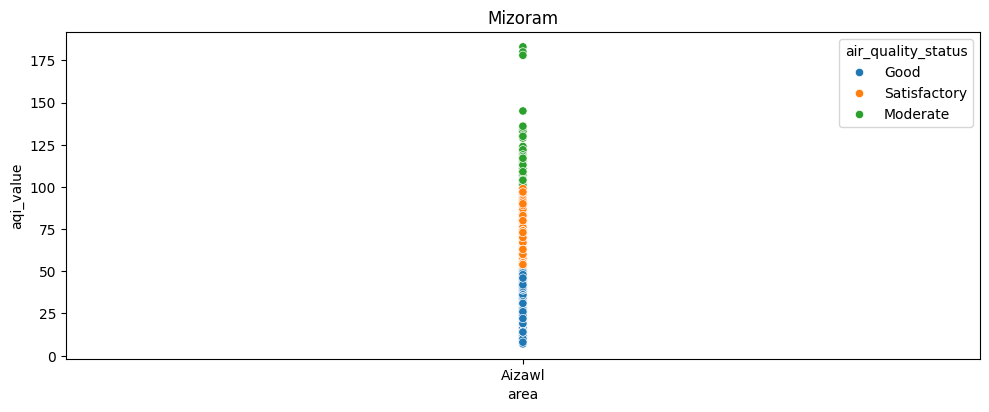

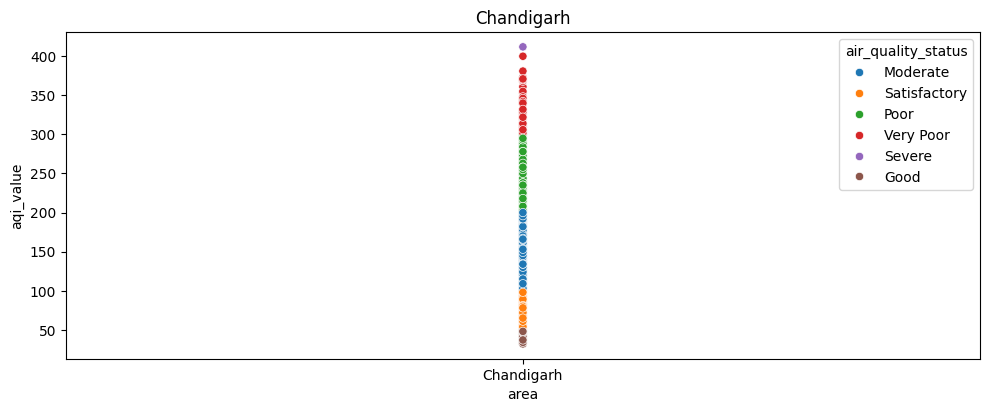

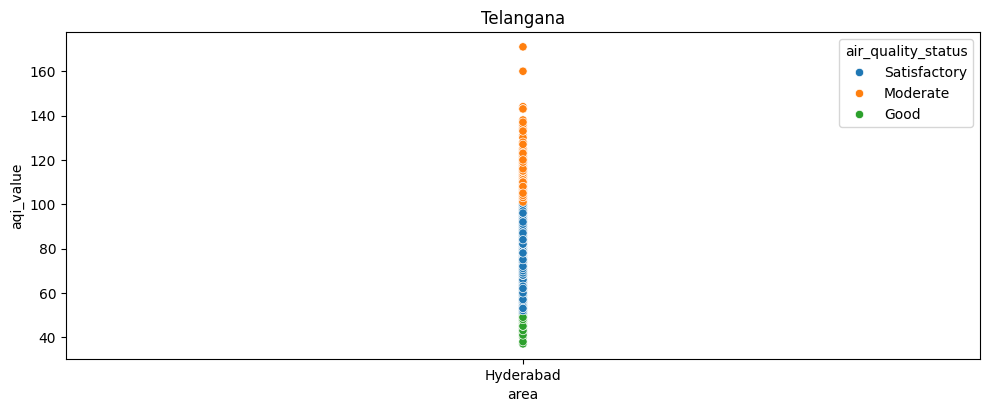

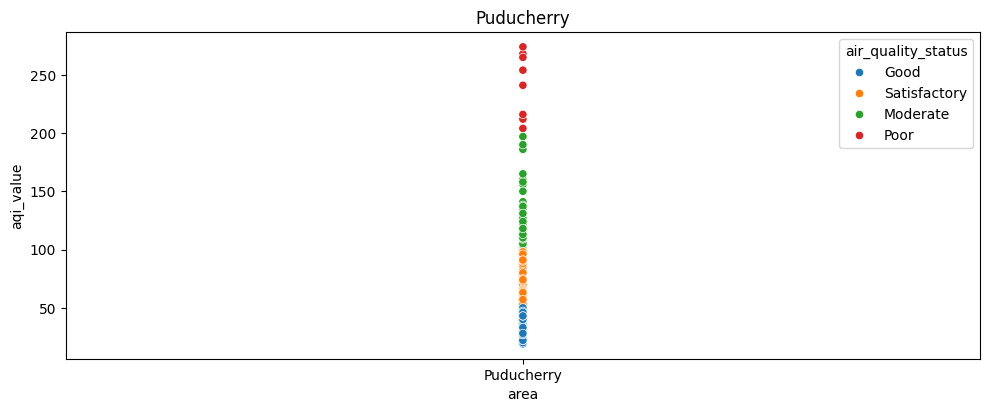

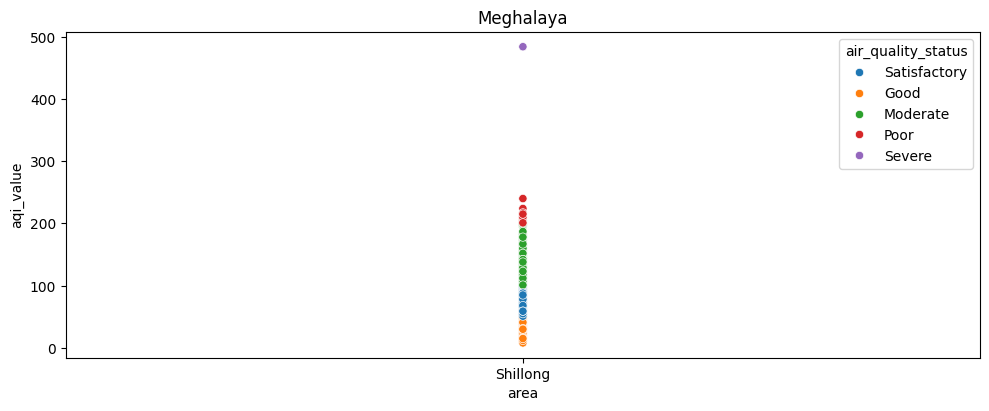

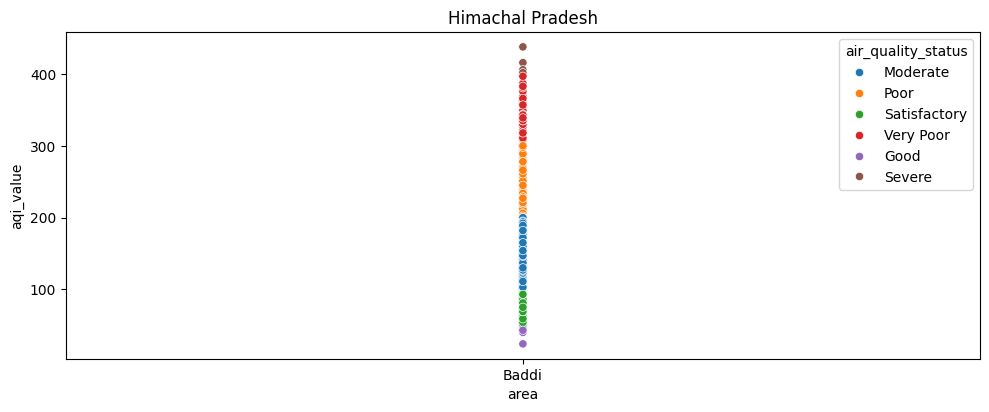

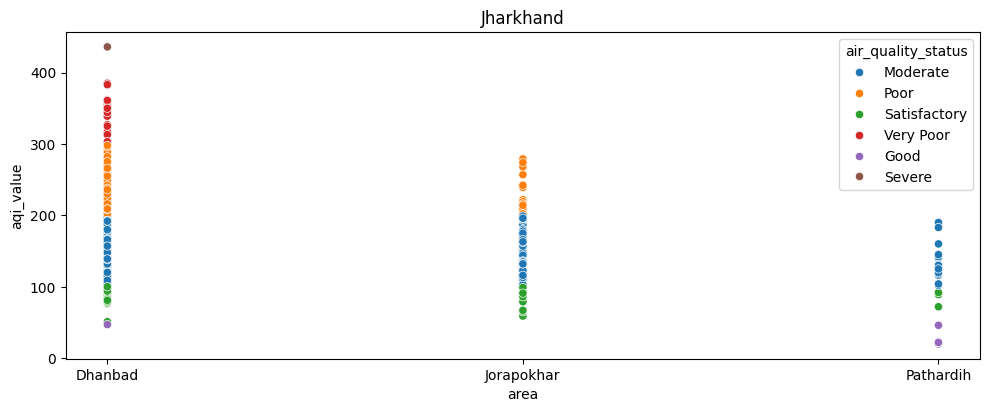

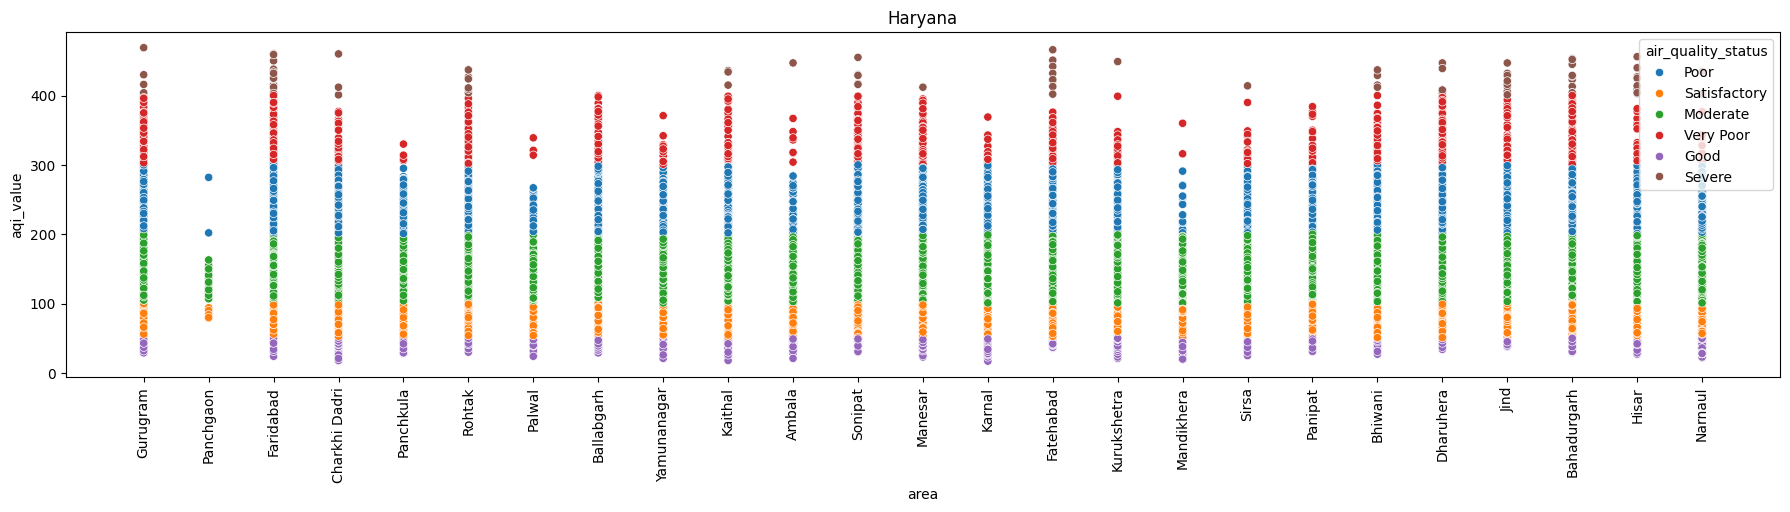

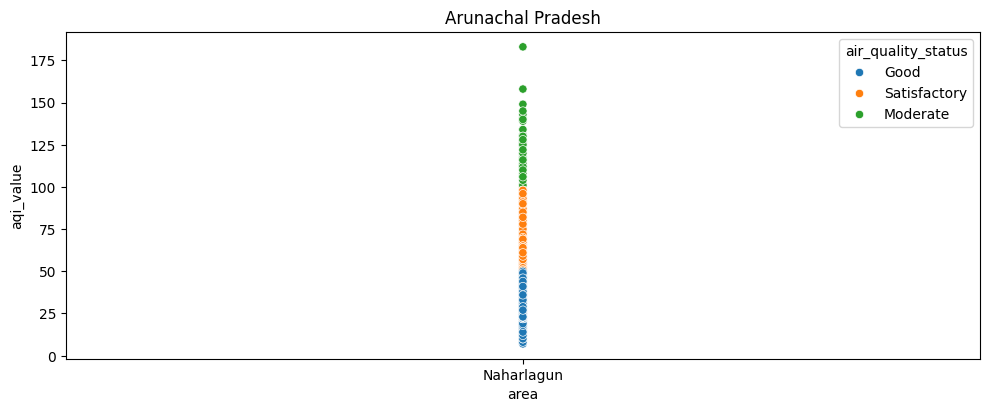

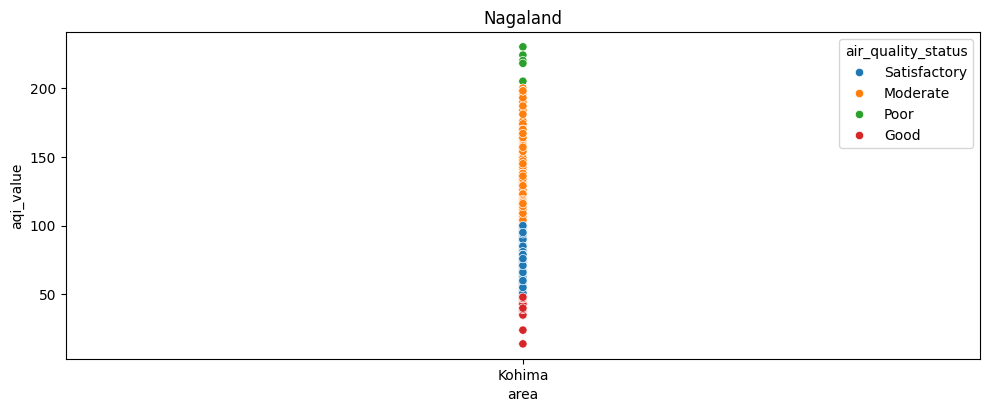

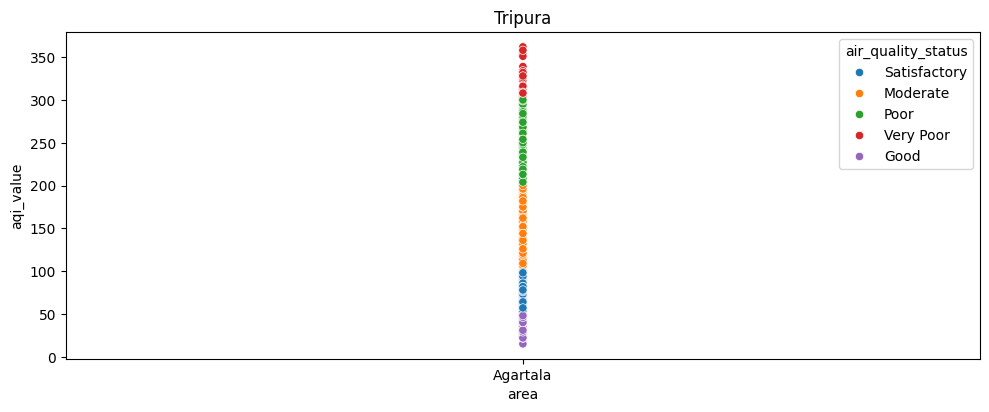

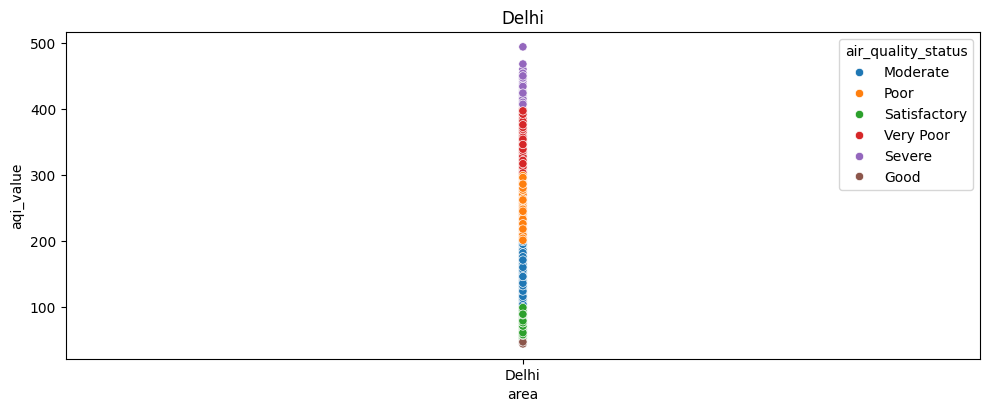

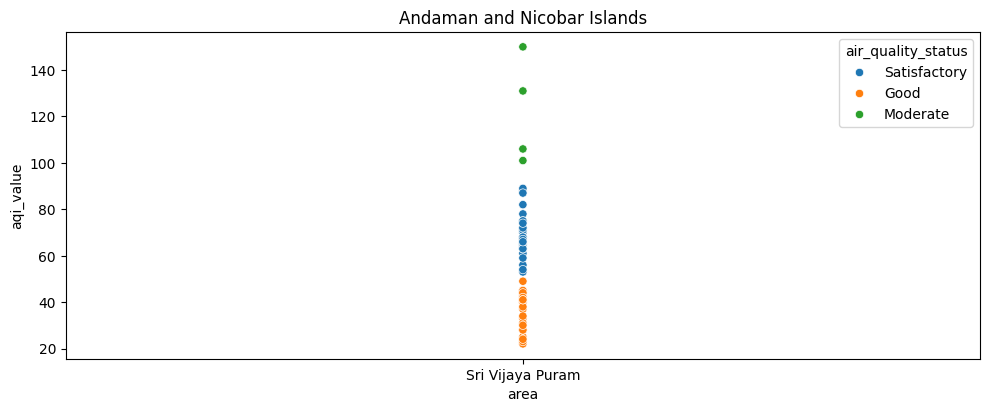

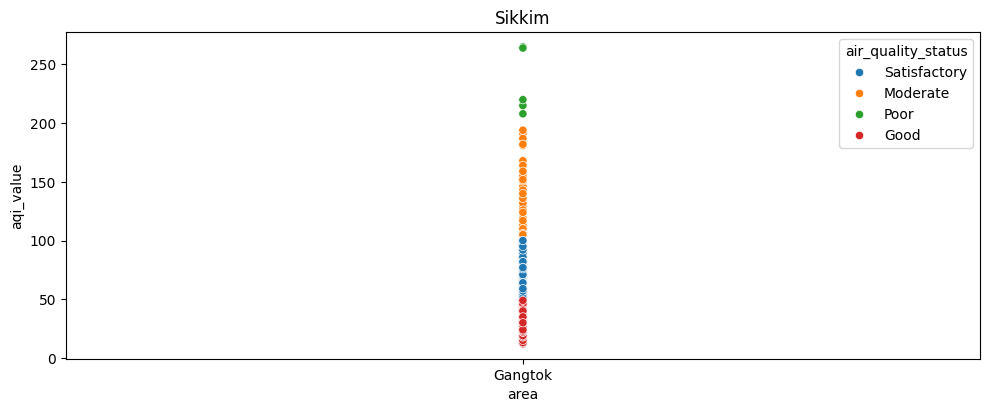

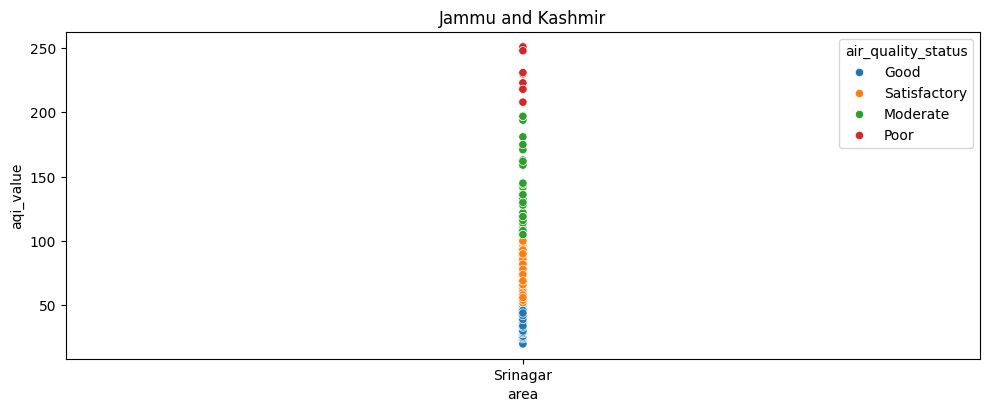

In [70]:
states = df['state'].unique()



for i in states:
    state_df = df[df['state'] == i]

    if (df[df['state'] == i]['area'].nunique()) <= 8:           # the states which has <= 3 area in the aqi, chaning their figure size
        plt.figure(figsize=(10, 4))
        sns.scatterplot(data=state_df, x='area', y='aqi_value', hue='air_quality_status')
        # plt.xticks(rotation=90)
        plt.tight_layout()
        plt.title(f"{i}")
        plt.show()
    else:
        plt.figure(figsize=(18, 5))
        sns.scatterplot(data=state_df, x='area', y='aqi_value', hue='air_quality_status')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.title(f"{i}")
        plt.show()



